# Convolutional Neural Networks
1. Kernels und Faltungen
2. Faltungen von Bildern
3. Pooling
4. 

In [ ]:
using Pkg
environmentName = "09-cnn"
Pkg.activate(joinpath(dirname(pwd()), "conf", environmentName))
Pkg.instantiate();

  Activating project at `/media/johannes/DATA/Syncthing/Programmierung/MathData-SoSe22/conf/08-cnn`


# Vorbereitung von Pfaden und Konfiguration des Notebooks
Das Training des CNN dauert einige Minuten. Nach dem Training werden die Gewichte des CNN gespeichert und des kann anschließend geladen werden. Damit kann dasselbe Netz zum Experimentieren verwendet werden. Außerdem kann das Notebook den Trainingsschritt überspringen, was während Live-Vorstellungen des Notebooks sinnvoll ist.

In [2]:
# Batch training kann bessere Ergenisse liefern, hängt aber von Fall zu Fall ab und bedarf Experimente
use_batch_training = true
# Falls das CNN trainiert werden soll, kann die immer gleiche Initialisierung des CNN verwendet werden, um vergleichbare Resultate beim Training zu erzeugen
load_cnn_init_weights = true
# Training überspringen und das trainierte CNN verwenden
load_trained_model = true

# Pfade
data_path = joinpath(dirname(pwd()), "data", environmentName)
cnn_trained_model_path = joinpath(data_path, "cnn_trained.jld2")
cnn_init_model_path = joinpath(data_path, "cnn_init.jld2")

"/media/johannes/DATA/Syncthing/Programmierung/MathData-SoSe22/data/08-cnn/cnn_init.jld2"

Hilfsfunktion
wandelt (x, n) um in einen 0-1-Vektor der Länge n mit Wert 1 an Index x und sont Wert 0

In [ ]:
using MLDatasets

ENV["DATADEPS_ALWAYS_ACCEPT"] = true

X_train, Y_train = FashionMNIST(split=:train)[:];
X_test, Y_test = FashionMNIST(split=:test)[:];

# Label der Klassen (Y enthält nur Zahlen 1-10)
labels = ["T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"];

# Klassen 1-indzieren
Y_train = Y_train .+ 1; 
Y_test = Y_test .+ 1; 

# Größe des Datensatzes berechnen
n_train = length(X_train[1, 1, :])
n_test = length(X_test[1, 1, :])
n_classes = length(labels)

# größe der Bilder herausfinden, in dem die Dimension des ersten Bildes abgefragt wird
image_size = size(X_train[:, :, 1])
input_size = prod(image_size)
width = image_size[1]
height = image_size[2]

# Daten in Liste von Vektoren umwandeln
onehot(x, n) = [ x == i ? 1.0 : 0.0 for i in 1:n ]
X_train = reshape(X_train, (input_size, n_train))
Y_train = [onehot(Y_train[i], n_classes) for i in 1:n_train]
X_test = reshape(X_test, (input_size, n_test))
Y_test = [onehot(Y_test[i], n_classes) for i in 1:n_test]

# Klassen der ersten 10 Trainingsbilder in one-hot-Encoding
Y_train[1:10, :]

10×1 Matrix{Vector{Float64}}:
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
 [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]
 [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]

# Kernel

Zuerst betrachten wir verschiedene Kernel und deren Effekte auf Bilder. Der erste Kernel nennt sich Sobel-Kernel und wird zur Erkennung von vertikalen Kanten verwendet.

In [5]:
sobel_filter = [1 0 -1; 2 0 -2; 1 0 -1]


3×3 Matrix{Int64}:
 1  0  -1
 2  0  -2
 1  0  -1

Layer 1 geht wie folgt vor:
- füge am Rand des Bilders 0en hinzu, d.h. wandle das 28x28 Bild in ein 30x30 Bild mit leerem Rand um
- verwende 16 3x3 Kernel und erzeuge dadurch 16 28x28 Kanäle

Layer 2:
- reduziere die Größe jedes Kanals durch den 2x2 max-pooling Operator auf 14x14

Layer 3:
- gehe wie Layer 1, allerdings sind die Bilder/Kanäle nur 14x14 groß
- wandle 16 Kanäle in 32 um

Layer 4:
- reduziere die Kanalgröße von 14x14 auf 7x7 mit dem 2x2 max-pooling Operator

Zwischen Layer 4 und Layer 5 werden die 32 7x7 Kanäle in einen Vektor der Größe 32 * 7 * 7 = 1568 umgewandelt. Die nächsten zwei Layer stellen ein ditch-vernetztes Neuronales Netz dar.

Layer 5:
- Dense Layer mit 1568 Eingabewerte und 90 Ausgabewerten und ReLu Aktivierungsfunktion

Layer 6:
- Dense Layer mit 90 Eingabewerte und 30 Ausgabewerten und ReLu Aktivierungsfunktion

Layer 7:
- Dense Layer mit 30 Eingabewerte und 10 Ausgabewerten und ReLu Aktivierungsfunktion

Layer 7:
- Softmax Layer von NNlib. Wichtig: Nicht Flux.softmax verwenden, das funktioniert nicht!

Die Ausgabe von Layer 6 wird mit einer Softmax Funktion versehen, damit die Ausgabe des Neuronalen Netzes als Verteilung auf der Menge der Klassen interpretiert werden kann.

In [6]:
# https://spcman.github.io/getting-to-know-julia/deep-learning/vision/flux-cnn-zoo/

using Flux

CNN = Flux.Chain(
    Flux.Conv((3, 3), 1 => 10, pad=(1, 1), relu),
    Flux.Conv((3, 3), 10 => 20, pad=(1, 1), relu),
    x -> maxpool(x, (2, 2)),
    Flux.Conv((3, 3), 20 => 30, pad=(1, 1), relu),
    x -> maxpool(x, (2, 2)),
    x -> reshape(x, 7 * 7 * 30),
    Flux.Dense(7 * 7 * 30, 7 * 7 * 5, relu),
    Flux.Dense(7 * 7 * 5, 7 * 5, relu),
    Flux.Dense(7 * 5, length(labels), relu),
    NNlib.softmax
)

Chain(
  Conv((3, 3), 1 => 10, relu, pad=1),   # 100 parameters
  Conv((3, 3), 10 => 20, relu, pad=1),  # 1_820 parameters
  var"#17#20"(),
  Conv((3, 3), 20 => 30, relu, pad=1),  # 5_430 parameters
  var"#18#21"(),
  var"#19#22"(),
  Dense(1470 => 245, relu),             # 360_395 parameters
  Dense(245 => 35, relu),               # 8_610 parameters
  Dense(35 => 10, relu),                # 360 parameters
  NNlib.softmax,
)                   # Total: 12 arrays, 376_715 parameters, 1.438 MiB.

In [7]:
using JLD2

if load_cnn_init_weights && isfile(cnn_init_model_path)
    # Modell laden
    model_state = JLD2.load(cnn_init_model_path, "model_state");
    Flux.loadmodel!(CNN, model_state)
else
    # Modell speichern
    model_state = Flux.state(CNN)
    jldsave(cnn_init_model_path; model_state)
end

Chain(
  Conv((3, 3), 1 => 10, relu, pad=1),   # 100 parameters
  Conv((3, 3), 10 => 20, relu, pad=1),  # 1_820 parameters
  var"#17#20"(),
  Conv((3, 3), 20 => 30, relu, pad=1),  # 5_430 parameters
  var"#18#21"(),
  var"#19#22"(),
  Dense(1470 => 245, relu),             # 360_395 parameters
  Dense(245 => 35, relu),               # 8_610 parameters
  Dense(35 => 10, relu),                # 360 parameters
  NNlib.softmax,
)                   # Total: 12 arrays, 376_715 parameters, 1.438 MiB.

In [8]:
loss(model, x, y) = Flux.crossentropy(model(x), y; dims = 1)

function create_batches(dataset, batch_size)
    batches = []
    for i in 1:batch_size:length(dataset)
        batch = dataset[i:min(i + batch_size - 1, length(dataset))]
        push!(batches, batch)
    end
    return batches
end

dataset_training_cnn = [(reshape(X_train[:, i], (width, height, 1, 1)), Float32.(Y_train[i])) for i in 1:n_train];
dataset_test_cnn = [(reshape(X_test[:, i], (width, height, 1, 1)), Float32.(Y_test[i])) for i in 1:n_test];
batches_cnn = create_batches(dataset_training_cnn, 100);

Nachfolgend wird das CNN mit kleinen Batches trainiert anstatt mit dem gesamten Dataset auf einmal. Dies hat experimentell für dieses Notebook wesentlich bessere Ergebnisse erzielt und wird deshalb verwendet.

In [9]:
if load_trained_model && isfile(cnn_trained_model_path)
    model_state = JLD2.load(cnn_trained_model_path, "model_state");
    Flux.loadmodel!(CNN, model_state)
else
    opt_cnn = Flux.setup(Adam(), CNN)
    for epoch in 1:5
        if use_batch_training
            for i in 1:length(batches_cnn)
                Flux.train!(loss, CNN, batches_cnn[i], opt_cnn)
            end
        else
            Flux.train!(loss, CNN, dataset_training_cnn, opt_cnn)
        end
    end
    model_state = Flux.state(CNN)
    jldsave(cnn_trained_model_path; model_state)
end

function test_model(model, dataset, n)
    score = 0
    for i in 1:n
        score += argmax(model(dataset[i][1])) == argmax(dataset[i][2])
    end
    return score / n
end

println("Training Accuracy: ", floor(test_model(CNN, dataset_training_cnn, length(dataset_training_cnn)) * 100), "%")
println("Test Accuracy: ", floor(test_model(CNN, dataset_test_cnn, length(dataset_test_cnn)) * 100), "%")

Training Accuracy: 89.0%
Test Accuracy: 87.0%


In [10]:
function convolve_3x3(image, kernel, bias)
    image_width = size(image)[1]
    image_height = size(image)[2]

    result = zeros(Float32, image_width, image_height)

    for i in 1:image_width
        for j in 1:image_height
            result[i, j] = bias
            for i_off in -1:1
                for j_off in -1:1
                    if i + i_off < 1 || i + i_off > image_width || j + j_off < 1 || j + j_off > image_height
                        continue
                    end
                    result[i, j] += kernel[i_off + 2, j_off + 2] * image[i + i_off, j + j_off]
                end
            end
            # ReLU
            if result[i, j] < 0
                result[i, j] = 0
            end
        end
    end

    return result
end

convolve_3x3 (generic function with 1 method)

# Kernel untersuchen
Das CNN hat im ersten Layer Kernel gelernt, deren Effekte wir inspizieren können. Im folgenden wird zuerst das Originalbild ausgegeben und danach die Bilder, die entstehen, wenn das Originalbild mit dem jeweiligen i-ten Kernel des 1. Layers gefaltet wird.

In [11]:
using ImageShow

function show_kernel_image(target)
    images = [convert2image(FashionMNIST, reshape(dataset_test_cnn[target][1], (width, height)))]
    for i in 1:layer1_channels
        push!(images, convert2image(FashionMNIST, convolve_3x3(reshape(dataset_test_cnn[target][1], (width, height)), CNN[1].weight[:, :, :, i], CNN[1].bias[i])))
    end
    images
end

show_kernel_image (generic function with 1 method)

In [12]:
target_kernel = 1

println(CNN[1].bias[target_kernel])
CNN[1].weight[:, :, :, target_kernel]

-0.04963735


3×3×1 Array{Float32, 3}:
[:, :, 1] =
 -1.21373    -0.000767063   0.328779
 -0.950758   -0.214937     -0.199293
 -0.0740644  -0.661391     -0.156736

In [26]:
function get_cnn_output(test_image)
    input = dataset_test_cnn[test_image][1]

    # weirder Anzeige-Bug in Jupyter, weswegen ich hier erst das Eingabebild hinzufüge und dann später entferne...
    imagesL1 = [convert2image(FashionMNIST, reshape(input[:, :, 1, 1], (width, height)))]
    layer = 1
    L1_output = CNN[layer](input)
    for i in 1:size(L1_output)[3]
        push!(imagesL1, convert2image(FashionMNIST, reshape(L1_output[:, :, i, 1], size(L1_output)[1:2])))
    end
    imagesL1 = imagesL1[2:end]

    layer = 2
    L2_output = CNN[layer](L1_output)
    imagesL2 = [convert2image(FashionMNIST, reshape(dataset_test_cnn[test_image][1], (width, height)))]
    for i in 1:size(L2_output)[3]
        push!(imagesL2, convert2image(FashionMNIST, reshape(L2_output[:, :, i, 1], size(L2_output)[1:2])))
    end
    imagesL2 = imagesL2[2:end]

    layer = 3
    L3_output = CNN[layer](L2_output)
    imagesL3 = [convert2image(FashionMNIST, reshape(dataset_test_cnn[test_image][1], (width, height)))]
    for i in 1:size(L3_output)[3]
        push!(imagesL3, convert2image(FashionMNIST, reshape(L3_output[:, :, i, 1], size(L3_output)[1:2])))
    end
    imagesL3 = imagesL3[2:end]

    layer = 4
    L4_output = CNN[layer](L3_output)
    imagesL4 = [convert2image(FashionMNIST, reshape(dataset_test_cnn[test_image][1], (width, height)))]
    for i in 1:size(L4_output)[3]
        push!(imagesL4, convert2image(FashionMNIST, reshape(L4_output[:, :, i, 1], size(L4_output)[1:2])))
    end
    imagesL4 = imagesL4[2:end]

    layer = 5
    L5_output = CNN[layer](L4_output)
    imagesL5 = [convert2image(FashionMNIST, reshape(dataset_test_cnn[test_image][1], (width, height)))]
    for i in 1:size(L5_output)[3]
        push!(imagesL5, convert2image(FashionMNIST, reshape(L5_output[:, :, i, 1], size(L5_output)[1:2])))
    end
    imagesL5 = imagesL5[2:end]

    return imagesL1, imagesL2, imagesL3, imagesL4, imagesL5
end

get_cnn_output (generic function with 1 method)

Das erste Test-Bild ist ein Schuh.

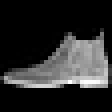

In [27]:
convert2image(FashionMNIST, reshape(dataset_test_cnn[1][1], (width, height)))

Nach dem ersten Layer ist im zweiten Kanal erahnbar, dass hier Schuhsohlen oder zumindest horizontale Kanten erkannt werden. Die anderen Kanäle sind eher kryptisch.

,,,,,,,,,

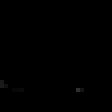
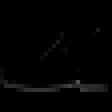
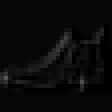
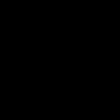
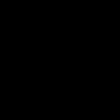
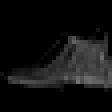
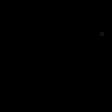
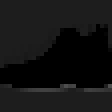
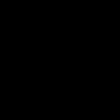
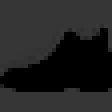

In [28]:
L1, L2, L3, L4, L5 = get_cnn_output(1)
L1

Nach dem zweiten Layer enthält der erste und 16. Kanal scheinbar nach linksoben-gerichtete Kanten. Der dritte und vierte Kanal enthält merkwürdige Artefakte.

,,,,,,,,,,,,,,,,,,,

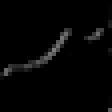
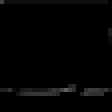
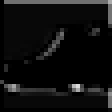
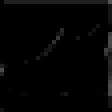
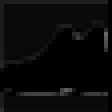
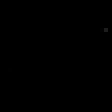
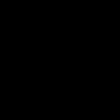
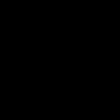
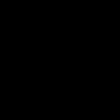
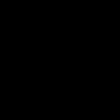
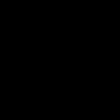
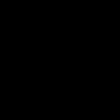
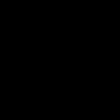
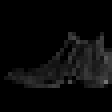
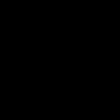
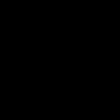
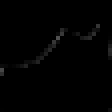
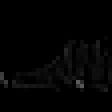
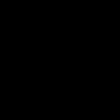
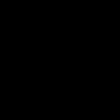

In [29]:
L2

Der dritte Layer ist ein max-pooling. Die Bilder werden von 28x28 nach 14x14 verkleinert.

,,,,,,,,,,,,,,,,,,,

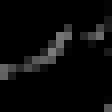
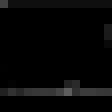
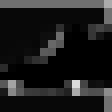
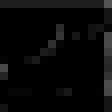
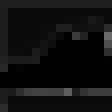
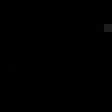
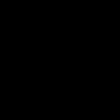
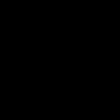
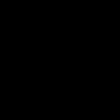
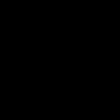
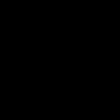
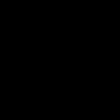
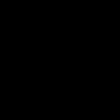
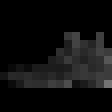
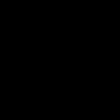
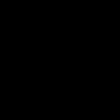
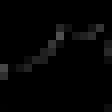
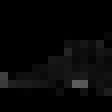
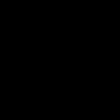
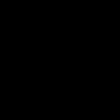

In [30]:
L3

Nach dem vierten Layer entstehen nun sehr viel kryptischere Kanäle. Der erste Kanal enthält ähnliche Daten wie der erste Kanal von Layer 2.

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

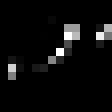
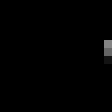
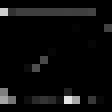
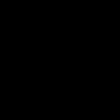
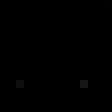
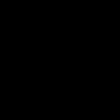
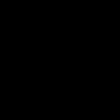
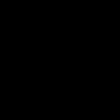
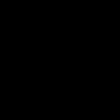
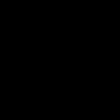
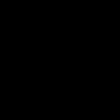
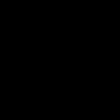
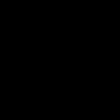
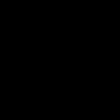
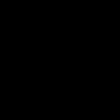
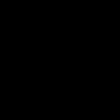
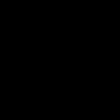
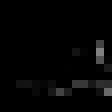
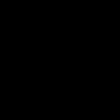
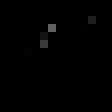
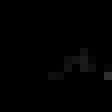
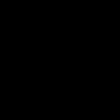
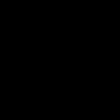
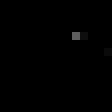
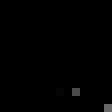
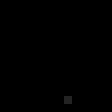
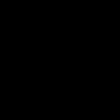
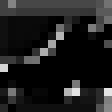
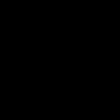
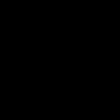

In [31]:
L4

Spätestens nach der letzten Faltung ist die Ausgabe weitesgehend kryptisch. Der erste Kanal hat z.T. den Charakter wie in den vorherigen Kanälen beibehalten.

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

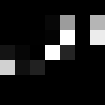
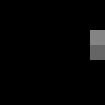
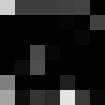
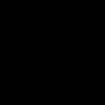
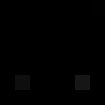
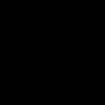
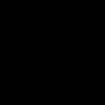
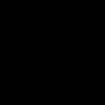
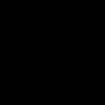
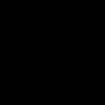
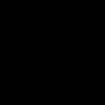
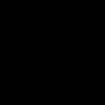
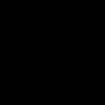
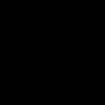
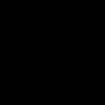
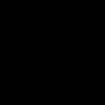
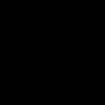
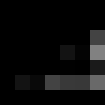
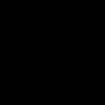
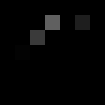
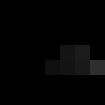
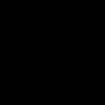
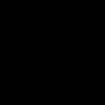
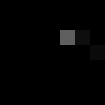
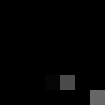
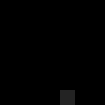
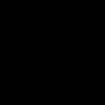
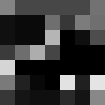
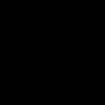
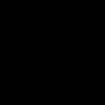

In [32]:
L5

Als nächstes betrachten wir noch eine Jacke. Der erste Kanal in Layer 2 bis 5 scheint hier ganz andere Ausgaben zu liefern als im vorherigen Bild. Erst werden wie bisher nach oben-links gerichtete Kanten hervorgehogen, aber dann oben-rechts.

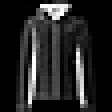

In [34]:
convert2image(FashionMNIST, reshape(dataset_test_cnn[7][1], (width, height)))

,,,,,,,,,

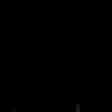
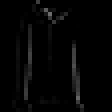
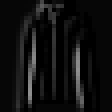
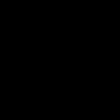
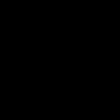
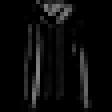
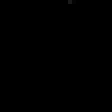
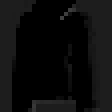
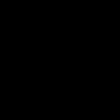
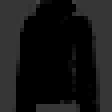

In [35]:
L1, L2, L3, L4, L5 = get_cnn_output(7)
L1

,,,,,,,,,,,,,,,,,,,

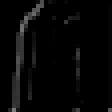
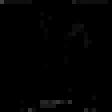
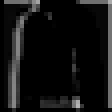
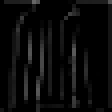
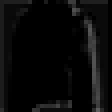
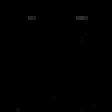
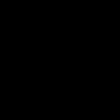
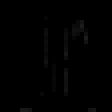
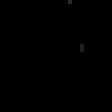
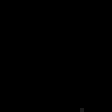
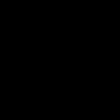
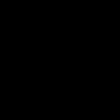
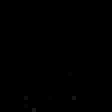
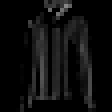
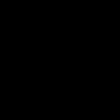
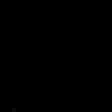
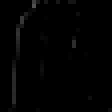
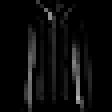
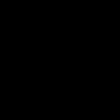
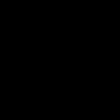

In [36]:
L2

,,,,,,,,,,,,,,,,,,,

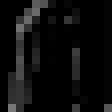
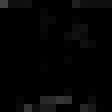
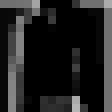
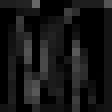
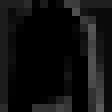
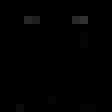
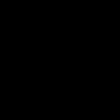
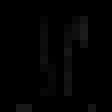
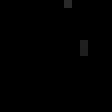
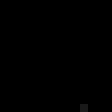
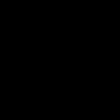
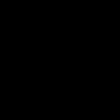
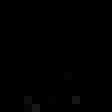
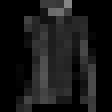
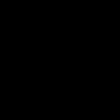
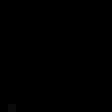
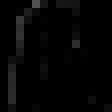
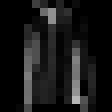
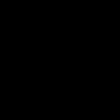
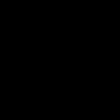

In [37]:
L3

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

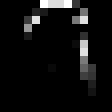
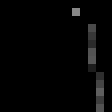
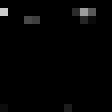
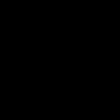
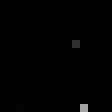
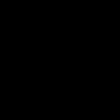
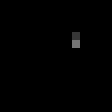
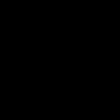
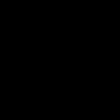
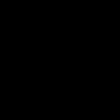
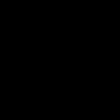
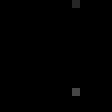
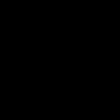
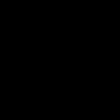
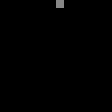
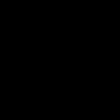
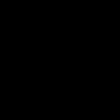
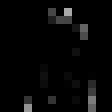
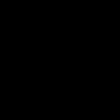
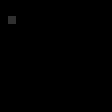
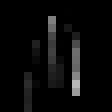
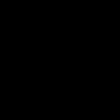
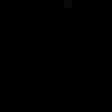
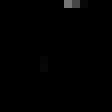
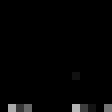
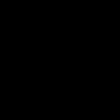
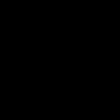
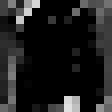
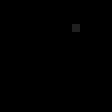
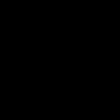

In [38]:
L4

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

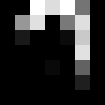
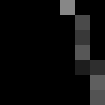
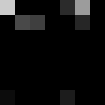
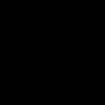
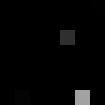
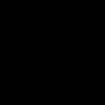
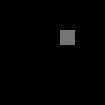
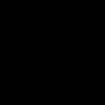
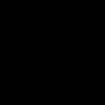
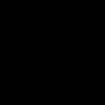
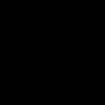
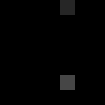
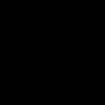
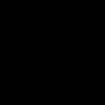
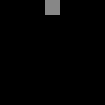
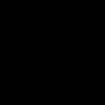
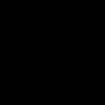
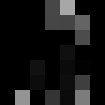
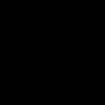
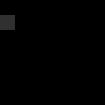
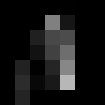
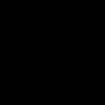
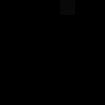
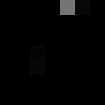
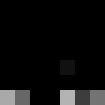
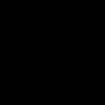
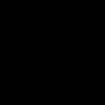
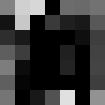
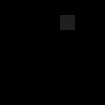
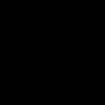

In [39]:
L5